<a href="https://colab.research.google.com/github/rafaelschaves/eel6034-prob-var-aleatorias/blob/master/distributions_vizualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')

In [16]:
class DistributionVisualizer:

    def __init__(self, distribution):
        self.distribution = distribution

    def _prepare_parameters(
        self,
        xmin=None,
        xmax=None,
        **params
    ):
        """
        Processa parâmetros e domínio.
        """

        params.setdefault("loc", 0)
        params.setdefault("scale", 1)

        lengths = []

        for value in params.values():

            if np.isscalar(value):
                lengths.append(1)

            else:
                lengths.append(len(value))

        n_curves = max(lengths)

        expanded_params = {}

        for key, value in params.items():

            if np.isscalar(value):

                expanded_params[key] = [value] * n_curves

            else:

                value = list(value)

                if len(value) == 1:

                    expanded_params[key] = (
                        value * n_curves
                    )

                elif len(value) == n_curves:

                    expanded_params[key] = value

                else:

                    raise ValueError(
                        f"Parâmetro '{key}' "
                        f"possui tamanho inválido."
                    )

        if xmin is None or xmax is None:

            locs = expanded_params.get(
                "loc",
                [0]
            )

            scales = expanded_params.get(
                "scale",
                [1]
            )

            xmin_auto = min(
                loc - 4 * scale
                for loc, scale in zip(
                    locs,
                    scales
                )
            )

            xmax_auto = max(
                loc + 4 * scale
                for loc, scale in zip(
                    locs,
                    scales
                )
            )

            xmin = (
                xmin
                if xmin is not None
                else xmin_auto
            )

            xmax = (
                xmax
                if xmax is not None
                else xmax_auto
            )

        return (
            expanded_params,
            n_curves,
            xmin,
            xmax
        )

    def _create_labels(
        self,
        curve_params
    ):

        return ", ".join(
            f"{k}={v}"
            for k, v
            in curve_params.items()
        )

    def pdf(
        self,
        xmin=None,
        xmax=None,
        num_points=1000,
        title="PDF",
        **params
    ):

        (
            expanded_params,
            n_curves,
            xmin,
            xmax
        ) = self._prepare_parameters(
            xmin=xmin,
            xmax=xmax,
            **params
        )

        x = np.linspace(
            xmin,
            xmax,
            num_points
        )

        plt.figure(figsize=(8,5))

        for i in range(n_curves):

            curve_params = {
                k: v[i]
                for k, v
                in expanded_params.items()
            }

            plt.plot(
                x,
                self.distribution.pdf(
                    x,
                    **curve_params
                ),
                linewidth=2,
                label=self._create_labels(
                    curve_params
                )
            )

        plt.title(title)
        plt.xlabel("x")
        plt.ylabel("PDF")
        plt.grid(True)
        plt.legend()
        plt.show()

    def cdf(
        self,
        xmin=None,
        xmax=None,
        num_points=1000,
        title="CDF",
        **params
    ):

        (
            expanded_params,
            n_curves,
            xmin,
            xmax
        ) = self._prepare_parameters(
            xmin=xmin,
            xmax=xmax,
            **params
        )

        x = np.linspace(
            xmin,
            xmax,
            num_points
        )

        plt.figure(figsize=(8,5))

        for i in range(n_curves):

            curve_params = {
                k: v[i]
                for k, v
                in expanded_params.items()
            }

            plt.plot(
                x,
                self.distribution.cdf(
                    x,
                    **curve_params
                ),
                linewidth=2,
                label=self._create_labels(
                    curve_params
                )
            )

        plt.title(title)
        plt.xlabel("x")
        plt.ylabel("CDF")
        plt.grid(True)
        plt.legend()
        plt.show()

    def histogram(
        self,
        sample_size=10000,
        bins=50,
        xmin=None,
        xmax=None,
        num_points=1000,
        title="Histograma",
        **params
    ):

        (
            expanded_params,
            n_curves,
            xmin,
            xmax
        ) = self._prepare_parameters(
            xmin=xmin,
            xmax=xmax,
            **params
        )

        x = np.linspace(
            xmin,
            xmax,
            num_points
        )

        plt.figure(figsize=(8,5))

        for i in range(n_curves):

            curve_params = {
                k: v[i]
                for k, v
                in expanded_params.items()
            }

            samples = (
                self.distribution.rvs(
                    size=sample_size,
                    **curve_params
                )
            )

            plt.hist(
                samples,
                bins=bins,
                density=True,
                alpha=0.3
            )

            plt.plot(
                x,
                self.distribution.pdf(
                    x,
                    **curve_params
                ),
                linewidth=2,
                label=self._create_labels(
                    curve_params
                )
            )

        plt.title(title)
        plt.xlabel("x")
        plt.ylabel("Densidade")
        plt.grid(True)
        plt.legend()
        plt.show()

    def sample(
        self,
        size=1000,
        random_state=None,
        **params
    ):
        """
        Gera amostras aleatórias.
        """

        return self.distribution.rvs(
            size=size,
            random_state=random_state,
            **params
        )

    def probability(
        self,
        a,
        b,
        **params
    ):
        """
        Calcula P(a <= X <= b).
        """

        return (
            self.distribution.cdf(b, **params)
            -
            self.distribution.cdf(a, **params)
        )

    def summary(
        self,
        **params
    ):
        """
        Exibe estatísticas teóricas
        da distribuição.
        """

        mean = self.distribution.mean(
            **params
        )

        variance = self.distribution.var(
            **params
        )

        std = self.distribution.std(
            **params
        )

        skewness = self.distribution.stats(
            moments='s',
            **params
        )

        kurtosis = self.distribution.stats(
            moments='k',
            **params
        )

        print("Resumo da Distribuição")
        print("-" * 40)

        print(
            f"Média: {mean:.4f}"
        )

        print(
            f"Variância: {variance:.4f}"
        )

        print(
            f"Desvio padrão: {std:.4f}"
        )

        print(
            f"Assimetria: {float(skewness):.4f}"
        )

        print(
            f"Curtose: {float(kurtosis):.4f}"
        )

    def describe(
        self,
        sample_size=10000,
        **params
    ):
        """
        Compara estatísticas teóricas
        e empíricas.
        """

        samples = self.sample(
            size=sample_size,
            **params
        )

        print("Teórico")
        print("-" * 30)

        print(
            f"Média: "
            f"{self.distribution.mean(**params):.4f}"
        )

        print(
            f"Variância: "
            f"{self.distribution.var(**params):.4f}"
        )

        print("\nEmpírico")
        print("-" * 30)

        print(
            f"Média: "
            f"{np.mean(samples):.4f}"
        )

        print(
            f"Variância: "
            f"{np.var(samples):.4f}"
        )

    def quantile(
        self,
        p,
        **params
    ):
        """
        Retorna o quantil associado
        à probabilidade p.
        """

        return self.distribution.ppf(
            p,
            **params
        )

    def interval(
        self,
        confidence=0.95,
        **params
    ):
        """
        Retorna intervalo central.
        """

        return self.distribution.interval(
            confidence,
            **params
        )

    def _plot_shaded_probability(
        self,
        mask_function,
        label,
        xmin=None,
        xmax=None,
        num_points=2000,
        title=None,
        **params
    ):
        """
        Método interno para destacar regiões
        sob a PDF.
        """

        (
            expanded_params,
            n_curves,
            xmin_auto,
            xmax_auto
        ) = self._prepare_parameters(
            xmin=xmin,
            xmax=xmax,
            **params
        )

        if n_curves != 1:

            raise ValueError(
                "Este método aceita apenas "
                "uma distribuição por vez."
            )

        curve_params = {
            k: v[0]
            for k, v in expanded_params.items()
        }

        x = np.linspace(
            xmin_auto,
            xmax_auto,
            num_points
        )

        pdf = self.distribution.pdf(
            x,
            **curve_params
        )

        mask = mask_function(x)

        plt.figure(figsize=(8,5))

        plt.plot(
            x,
            pdf,
            linewidth=2
        )

        plt.fill_between(
            x[mask],
            pdf[mask],
            alpha=0.4,
            label=label
        )

        plt.xlabel("x")
        plt.ylabel("PDF")

        if title:
            plt.title(title)

        plt.grid(True)
        plt.legend()

        plt.show()

    def plot_probability(
        self,
        a,
        b,
        **params
    ):
        """
        Destaca P(a <= X <= b).
        """

        probability = (
            self.distribution.cdf(
                b,
                **params
            )
            -
            self.distribution.cdf(
                a,
                **params
            )
        )

        self._plot_shaded_probability(
            mask_function=lambda x:
                (x >= a) & (x <= b),

            label=(
                f"P({a} ≤ X ≤ {b}) = "
                f"{probability:.4f}"
            ),

            title="Probabilidade entre dois pontos",

            **params
        )

        return probability

    def plot_probability_left(
        self,
        x0,
        **params
    ):
        """
        Destaca P(X <= x0).
        """

        probability = self.distribution.cdf(
            x0,
            **params
        )

        self._plot_shaded_probability(
            mask_function=lambda x:
                x <= x0,

            label=(
                f"P(X ≤ {x0}) = "
                f"{probability:.4f}"
            ),

            title="Probabilidade acumulada",

            **params
        )

        return probability

    def plot_probability_right(
        self,
        x0,
        **params
    ):
        """
        Destaca P(X >= x0).
        """

        probability = (
            1
            -
            self.distribution.cdf(
                x0,
                **params
            )
        )

        self._plot_shaded_probability(
            mask_function=lambda x:
                x >= x0,

            label=(
                f"P(X ≥ {x0}) = "
                f"{probability:.4f}"
            ),

            title="Probabilidade de cauda",

            **params
        )

        return probability

    def plot_critical_region_left(
        self,
        alpha=0.05,
        **params
    ):
        """
        Região crítica unilateral à esquerda.
        """

        x_critical = self.distribution.ppf(
            alpha,
            **params
        )

        probability = self.distribution.cdf(
            x_critical,
            **params
        )

        self._plot_shaded_probability(
            mask_function=lambda x:
                x <= x_critical,

            label=(
                f"α={alpha:.4f}\n"
                f"xc={x_critical:.4f}"
            ),

            title=(
                "Região Crítica "
                "(Cauda Esquerda)"
            ),

            **params
        )

        return x_critical, probability

    def plot_critical_region_right(
        self,
        alpha=0.05,
        **params
    ):
        """
        Região crítica unilateral à direita.
        """

        x_critical = self.distribution.ppf(
            1 - alpha,
            **params
        )

        probability = (
            1 -
            self.distribution.cdf(
                x_critical,
                **params
            )
        )

        self._plot_shaded_probability(
            mask_function=lambda x:
                x >= x_critical,

            label=(
                f"α={alpha:.4f}\n"
                f"xc={x_critical:.4f}"
            ),

            title=(
                "Região Crítica "
                "(Cauda Direita)"
            ),

            **params
        )

        return x_critical, probability

    def plot_critical_region_two_tailed(
        self,
        alpha=0.05,
        xmin=None,
        xmax=None,
        num_points=2000,
        **params
    ):
        """
        Região crítica bilateral.
        """

        (
            expanded_params,
            n_curves,
            xmin_auto,
            xmax_auto
        ) = self._prepare_parameters(
            xmin=xmin,
            xmax=xmax,
            **params
        )

        if n_curves != 1:

            raise ValueError(
                "Apenas uma distribuição."
            )

        curve_params = {
            k: v[0]
            for k, v
            in expanded_params.items()
        }

        x_lower = self.distribution.ppf(
            alpha/2,
            **curve_params
        )

        x_upper = self.distribution.ppf(
            1-alpha/2,
            **curve_params
        )

        x = np.linspace(
            xmin_auto,
            xmax_auto,
            num_points
        )

        pdf = self.distribution.pdf(
            x,
            **curve_params
        )

        plt.figure(figsize=(8,5))

        plt.plot(
            x,
            pdf,
            linewidth=2
        )

        mask_left = x <= x_lower

        mask_right = x >= x_upper

        plt.fill_between(
            x[mask_left],
            pdf[mask_left],
            alpha=0.4
        )

        plt.fill_between(
            x[mask_right],
            pdf[mask_right],
            alpha=0.4,
            label=(
                f"α={alpha:.4f}\n"
                f"[{x_lower:.4f}, "
                f"{x_upper:.4f}]"
            )
        )

        plt.axvline(
            x_lower,
            linestyle="--"
        )

        plt.axvline(
            x_upper,
            linestyle="--"
        )

        plt.title(
            "Região Crítica Bilateral"
        )

        plt.xlabel("x")
        plt.ylabel("PDF")

        plt.grid(True)
        plt.legend()

        plt.show()

        return x_lower, x_upper

In [12]:
from scipy.stats import norm

normal = DistributionVisualizer(
    norm
)

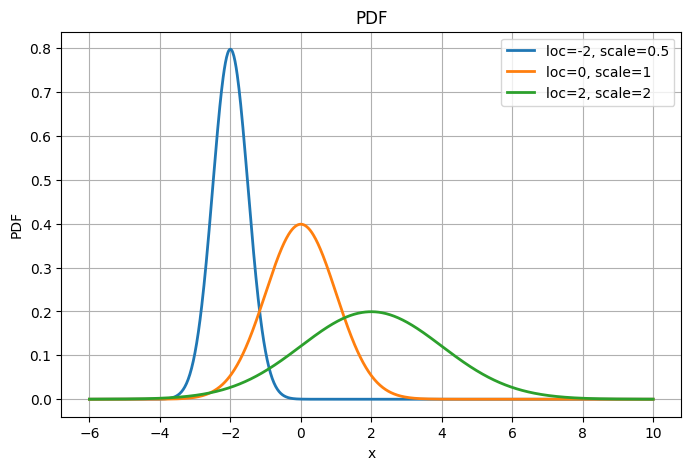

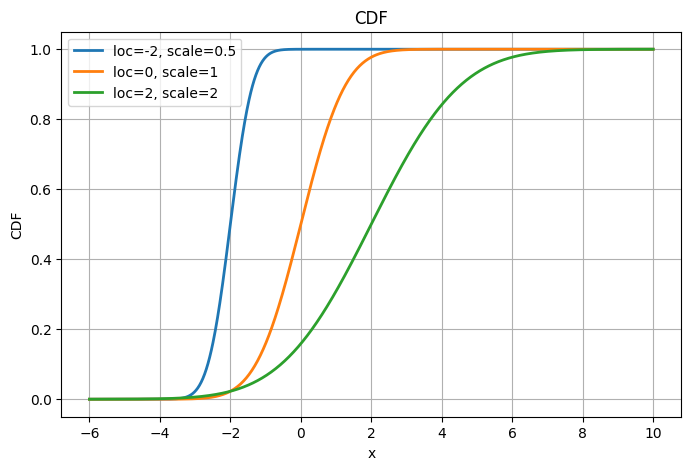

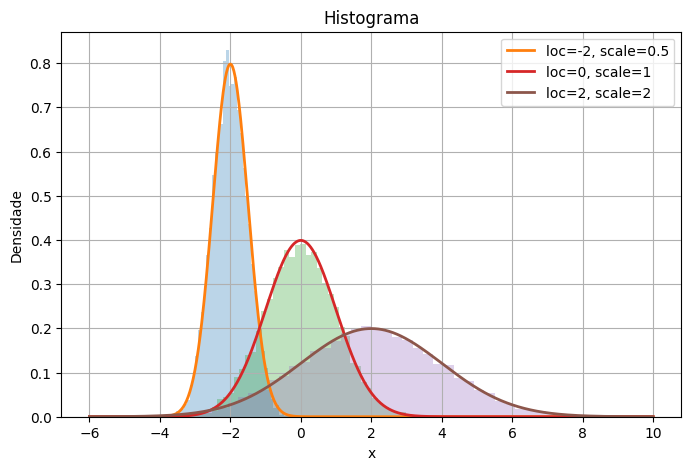

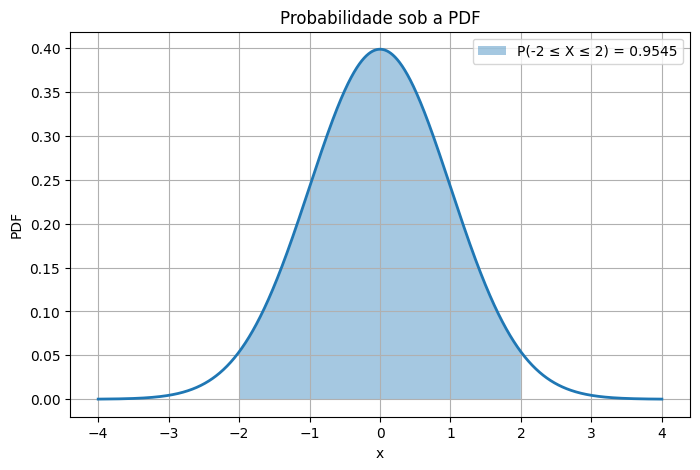

np.float64(0.9544997361036416)

In [14]:
normal.pdf(
    loc=[-2,0,2],
    scale=[0.5,1,2]
)

normal.cdf(
    loc=[-2,0,2],
    scale=[0.5,1,2]
)

normal.histogram(
    loc=[-2,0,2],
    scale=[0.5,1,2]
)

normal.plot_probability(
    a=-2,
    b=2
)

Importando a distribuição

Na SciPy, a uniforme é parametrizada por:

loc = a
scale = b-a

Portanto:

In [6]:
from scipy.stats import uniform

uniform_dist = DistributionVisualizer(
    uniform
)

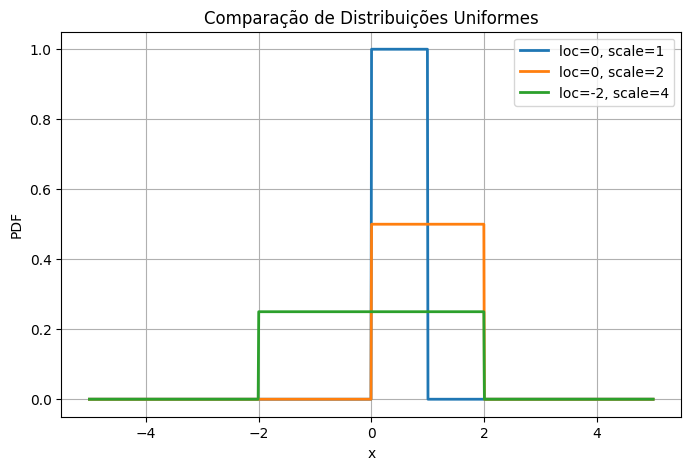

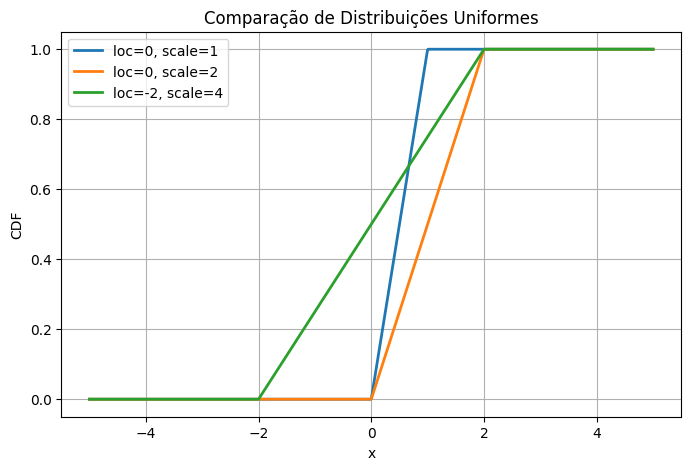

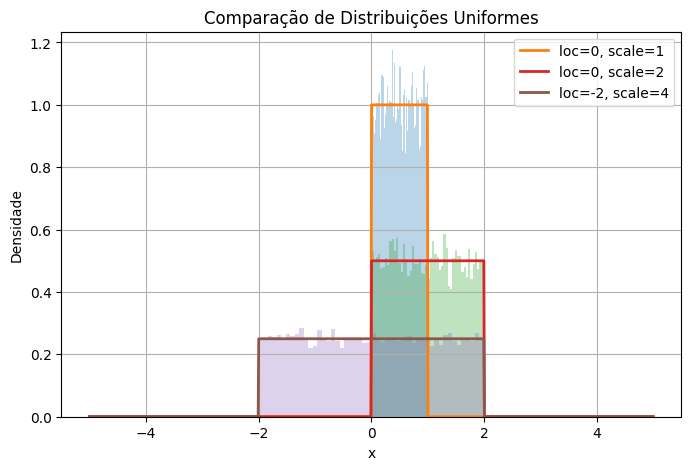

In [8]:
uniform_dist.pdf(
    xmin=-5,
    xmax=5,
    loc=[0, 0, -2],
    scale=[1, 2, 4],
    title="Comparação de Distribuições Uniformes"
)

uniform_dist.cdf(
    xmin=-5,
    xmax=5,
    loc=[0, 0, -2],
    scale=[1, 2, 4],
    title="Comparação de Distribuições Uniformes"
)

uniform_dist.histogram(
    xmin=-5,
    xmax=5,
    loc=[0, 0, -2],
    scale=[1, 2, 4],
    title="Comparação de Distribuições Uniformes"
)